<a href="https://colab.research.google.com/github/madanjha/Machine-Learning/blob/main/Covid19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Given data about COVID-19 patients, write code to visualize the impact and
analyze the trend of rate of infection and recovery as well as make predictions
about the number of cases expected a week in future based on the current
trends.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from math import sqrt

import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import *

In [30]:
df=pd.read_csv('/content/covid_19_clean_complete.csv')
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [32]:
df.shape

(49068, 10)

In [33]:
df.describe()

,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


In [34]:
df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [35]:
df.duplicated().sum()

np.int64(0)

## Prepare data

### Subtask:
Convert the 'Date' column to datetime objects and aggregate the data by date to get worldwide daily counts.


In [36]:
df['Date'] = pd.to_datetime(df['Date'])
worldwide_df = df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()
display(worldwide_df.head())

,Date,Confirmed,Deaths,Recovered
0,2020-01-22,555,17,28
1,2020-01-23,654,18,30
2,2020-01-24,941,26,36
3,2020-01-25,1434,42,39
4,2020-01-26,2118,56,52


Plot the daily confirmed, deaths, and recovered cases worldwide to visualize the overall impact and trends.
Plot the worldwide confirmed, recovered, and deaths cases over time to visualize the trends.





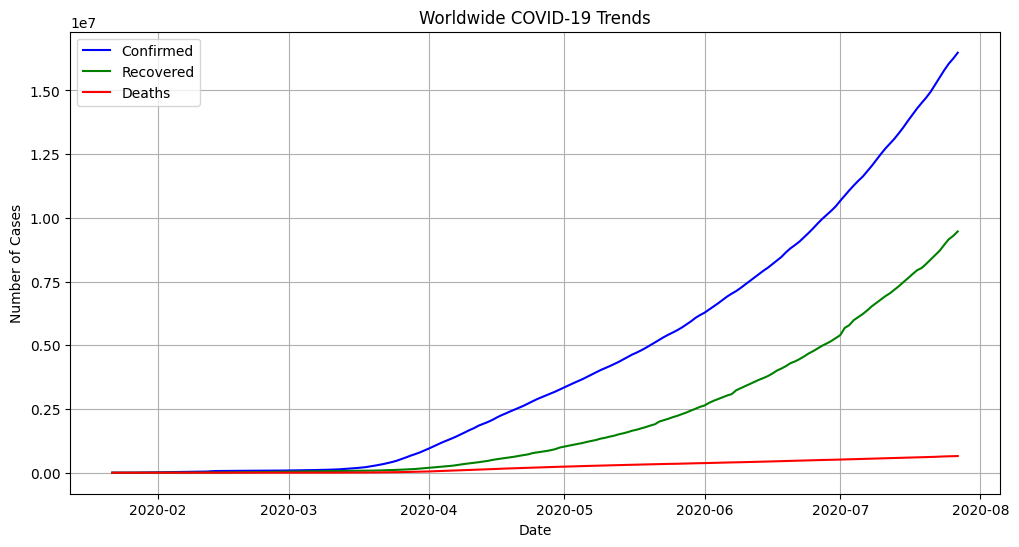

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(worldwide_df['Date'], worldwide_df['Confirmed'], label='Confirmed', color='blue')
plt.plot(worldwide_df['Date'], worldwide_df['Recovered'], label='Recovered', color='green')
plt.plot(worldwide_df['Date'], worldwide_df['Deaths'], label='Deaths', color='red')
plt.title('Worldwide COVID-19 Trends')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
worldwide_df['Daily Confirmed'] = worldwide_df['Confirmed'].diff()
worldwide_df['Daily Deaths'] = worldwide_df['Deaths'].diff()
worldwide_df['Daily Recovered'] = worldwide_df['Recovered'].diff()
display(worldwide_df.head())

,Date,Confirmed,Deaths,Recovered,Daily Confirmed,Daily Deaths,Daily Recovered
0,2020-01-22,555,17,28,NaN,NaN,NaN
1,2020-01-23,654,18,30,99.0,1.0,2.0
2,2020-01-24,941,26,36,287.0,8.0,6.0
3,2020-01-25,1434,42,39,493.0,16.0,3.0
4,2020-01-26,2118,56,52,684.0,14.0,13.0


Plot the daily increase in confirmed, deaths, and recovered cases to see the rate of change.


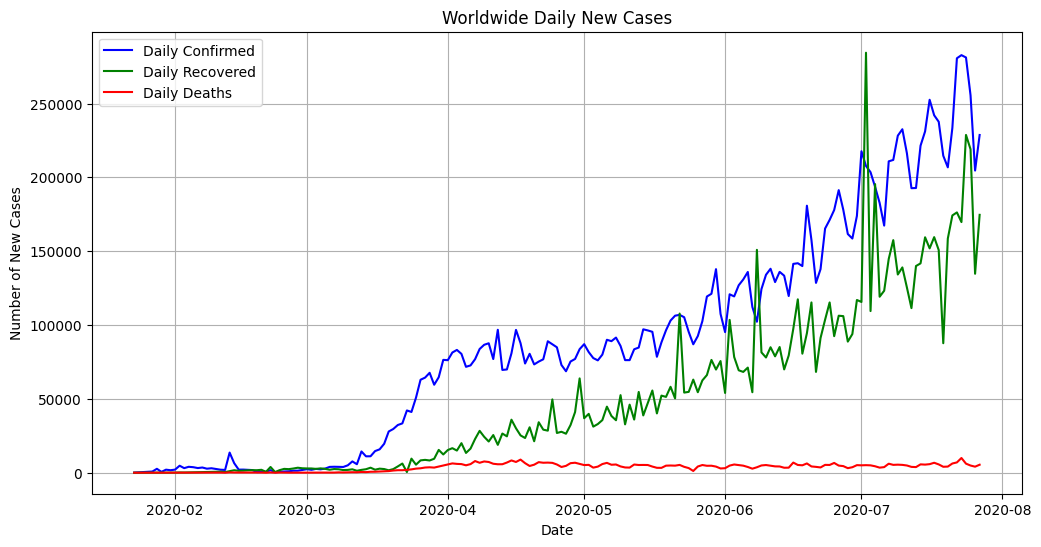

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(worldwide_df['Date'], worldwide_df['Daily Confirmed'], label='Daily Confirmed', color='blue')
plt.plot(worldwide_df['Date'], worldwide_df['Daily Recovered'], label='Daily Recovered', color='green')
plt.plot(worldwide_df['Date'], worldwide_df['Daily Deaths'], label='Daily Deaths', color='red')
plt.title('Worldwide Daily New Cases')
plt.xlabel('Date')
plt.ylabel('Number of New Cases')
plt.legend()
plt.grid(True)
plt.show()

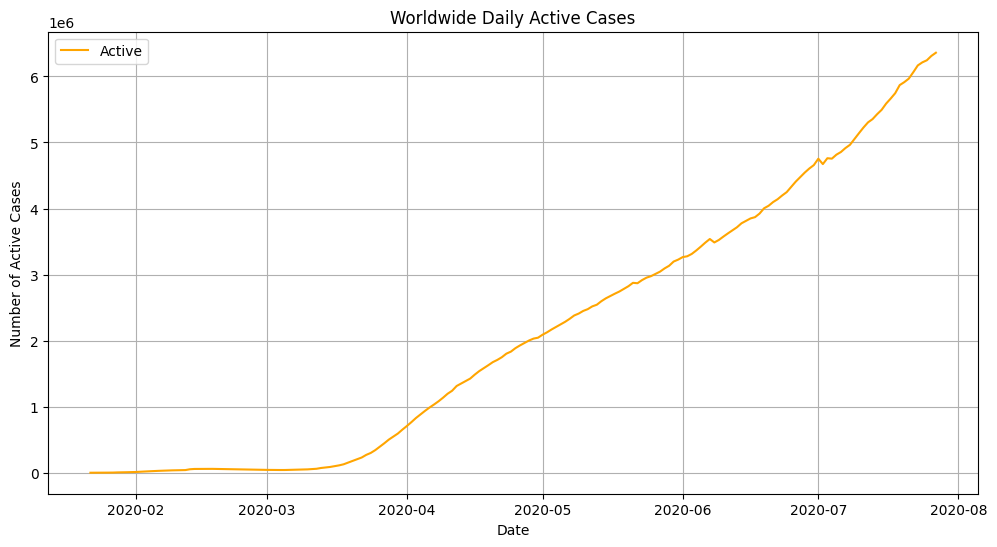

In [40]:
worldwide_df['Active'] = worldwide_df['Confirmed'] - worldwide_df['Deaths'] - worldwide_df['Recovered']

plt.figure(figsize=(12, 6))
plt.plot(worldwide_df['Date'], worldwide_df['Active'], label='Active', color='orange')
plt.title('Worldwide Daily Active Cases')
plt.xlabel('Date')
plt.ylabel('Number of Active Cases')
plt.legend()
plt.grid(True)
plt.show()

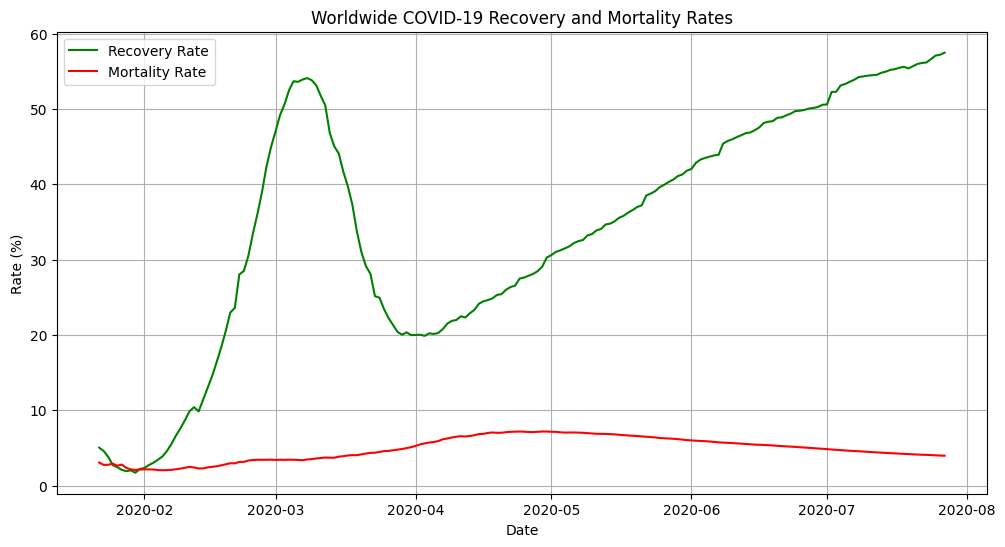

In [41]:
worldwide_df['Recovery Rate'] = (worldwide_df['Recovered'] / worldwide_df['Confirmed']) * 100
worldwide_df['Mortality Rate'] = (worldwide_df['Deaths'] / worldwide_df['Confirmed']) * 100

# Handle potential division by zero (Confirmed cases being 0)
worldwide_df['Recovery Rate'] = worldwide_df['Recovery Rate'].replace([np.inf, -np.inf], 0)
worldwide_df['Mortality Rate'] = worldwide_df['Mortality Rate'].replace([np.inf, -np.inf], 0)

plt.figure(figsize=(12, 6))
plt.plot(worldwide_df['Date'], worldwide_df['Recovery Rate'], label='Recovery Rate', color='green')
plt.plot(worldwide_df['Date'], worldwide_df['Mortality Rate'], label='Mortality Rate', color='red')
plt.title('Worldwide COVID-19 Recovery and Mortality Rates')
plt.xlabel('Date')
plt.ylabel('Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

In [42]:
prediction_df = worldwide_df[['Date', 'Confirmed']].copy()
prediction_df['Date'] = (prediction_df['Date'] - prediction_df['Date'].min()).dt.days
display(prediction_df.head())

,Date,Confirmed
0,0,555
1,1,654
2,2,941
3,3,1434
4,4,2118


## Split data for prediction

Split the data into training and testing sets for the prediction model.


In [43]:
X = prediction_df[['Date']]
y = prediction_df['Confirmed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (150, 1)
X_test shape: (38, 1)
y_train shape: (150,)
y_test shape: (38,)



Train a Linear Regression model on the training data.



In [44]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Create a DataFrame with future dates, convert them to numerical format, and use the trained model to predict confirmed cases for these dates.



In [45]:
last_date = prediction_df['Date'].max()
future_dates = pd.DataFrame({'Date': range(last_date + 1, last_date + 8)})
future_predictions = model.predict(future_dates)
print("Predicted confirmed cases for the next 7 days:")
print(future_predictions)

Predicted confirmed cases for the next 7 days:
[8862395.69702653 8919333.43197831 8976271.16693008 9033208.90188186
 9090146.63683363 9147084.37178541 9204022.10673719]


Plot the historical confirmed cases and the future predictions on the same plot to visualize the forecast.



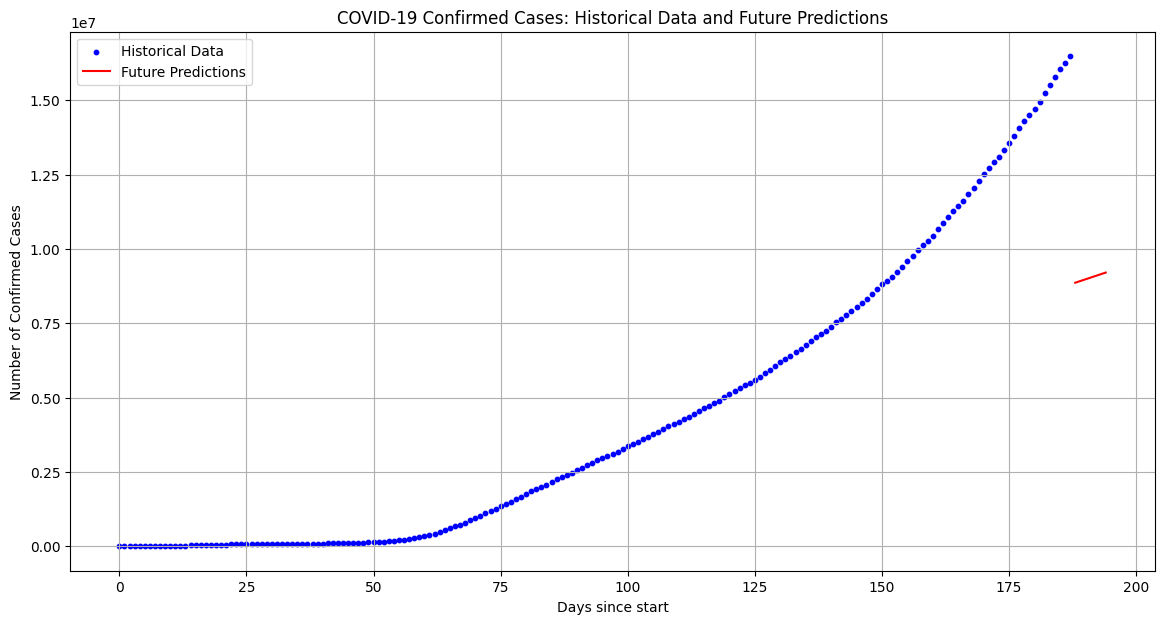

In [46]:
plt.figure(figsize=(14, 7))
plt.scatter(prediction_df['Date'], prediction_df['Confirmed'], label='Historical Data', color='blue', s=10)
plt.plot(future_dates['Date'], future_predictions, label='Future Predictions', color='red')
plt.title('COVID-19 Confirmed Cases: Historical Data and Future Predictions')
plt.xlabel('Days since start')
plt.ylabel('Number of Confirmed Cases')
plt.legend()
plt.grid(True)
plt.show()

## Summary:

### Data Analysis Key Findings

*   Worldwide confirmed, recovered, and death cases generally increased over the observed period.
*   Daily new confirmed cases show fluctuations, with periods of both increase and decrease.
*   Worldwide active cases demonstrated a significant increase over time.
*   The recovery rate generally increased over the period, while the mortality rate showed a decreasing trend after an initial phase.
*   The linear regression model predicted a continued increase in confirmed cases for the next 7 days.

### Insights or Next Steps

*   While a linear model provides a basic forecast, more sophisticated time series models (e.g., ARIMA, Prophet) could capture non-linear trends and seasonality for improved prediction accuracy.
*   Further analysis could investigate the impact of interventions (like lockdowns or vaccinations) on the infection and mortality rates.
